In [ ]:
Content
1. Theory
    1.1 Problem Identification
2. Traversal
3. Basic Tree Problems
4. Binary Search Tree
5. Tree Path Problems
6. Sub-Tree Problems
7. Comparing Trees
8. Tree Views
9. Tree Data Agumentation
10. LCA
11. Euler Tour
12. Tree Generic Problems
13. Serialize and Deserialize
14. Morris Traversal (Complex)

# 1. Theory

In [ ]:
Tree is a special type of graph which has N vertices and N-1 edges and each vertex should be connected.
It is Acyclic (ie. no closed loop or cyclic - start and end at same vertx) and connected graph.
- As b/w two nodes, there will be just one edge. 

- K-arity Tree: Every Node has k-children or 0. 
- Full Binary Tree: Which has either 2 children or 0 children.
- Complete Tree: Perfect tree and last level should be filled from left side.
- Perfect Binary Tree: (Maximum nodes) all nodes has 2 children except the last level and all leaf nodes are at same level.
- Number of nodes: 2 ^(h+1) - 1           # h is height of perfect tree starting from zero.
   => 2^0 + 2^1 + 2^2 => for a tree height of 2 (i.e  0, 1, 2 levels) it has 7 nodes.
- No. of intermediate Node: Its almost half of above = (2^h) -1
- Minimum number of nodes: Intermediate + 1
- For K-arity tree, sigma of K ^ height =>[[ (k^(h-1) - 1)  / k-1 ]] 
    
Tree height: calculate from bottom, and leaf nodes have height zero, irrespective of level.
Tree Depth: calculated from root, depth increases with the level.

N Node Tree
- Has N-1 edges
- N-1 nodes has parents.

Idea:
- Check if node is a leaf node or not
    - node.left is None and node.right is None

Time complexity:
    - Tree Traversal takes (N)
    - Balanced Binary Search Tree Traversal takes (log N)

In [ ]:

def solve(root, result):
    if (node == null):
        return 0  # Return can be Null, False, 0 based on question output
        
    l = solve(node.left, result)
    r = solve(node.right, result)

    result = function( node, l, r)
    return result

# All Tree problem can be solved with
Step 1. Find a base case
Step 2. Call the same function on left sub tree
Step 3. Call the same function on right sub tree
Step 4. Join the result considering root, left result and right result.

# The only question is: what do you return and how do you combine?

In [ ]:
1. DFS Traversal (with Recursion)
    - Visiting Every Node
    - Path sum, root-to-leaf path
    - DFS + Hashing
        - Tree Comparison

    - DFS + Backtracking
        - Path Problems: Path sum, all path, root-to-leaf path
        
    - Postorder DFS
        - height/ depth/ diameter
        - longest path

2. BFS Traversal (with Queue)
    - Involves Levels/ distance/ depth/ nearest/ distance from root
    - Views
    - Nodes per level

3. LCA (Lowest common ancestor)
    - Common Parent

4. BST ordering 
    - BST properties
    - Inorder traversal gives sorted array
    - kth smallest, Range Queries

5. Parent Pointers/ Binary Lifting
    - ancestor
    - K-th Node

6. Serialization
    - Subtree Comparison

7. Divide & Conquer
    - Tree Construction (all possible)

8. DFS comparison/ Tree Serialization/ hashing
    - subtree, tree equality, duplicate subtree

In [ ]:
+----------------------+---------------------+------------------+----------------------------+
| Pattern              | Algorithm           | Time Complexity  | Typical Problems           |
+----------------------+---------------------+------------------+----------------------------+
| Traversal            | DFS / BFS           | O(n)             | Inorder traversal          |
| Level operations     | BFS                 | O(n)             | Level order traversal      |
| Height/Depth         | DFS recursion       | O(n)             | Max depth of tree          |
| Path problems        | DFS + Backtracking  | O(n)             | Path sum                   |
| Lowest ancestor      | LCA                 | O(n) / O(log n)  | LCA in binary tree         |
| BST problems         | Inorder traversal   | O(n)             | Validate BST               |
| Tree construction    | Divide & Conquer    | O(n)             | Build tree from traversals |
| Subtree detection    | DFS + serialization | O(n)             | Same tree / subtree        |
| Diameter problems    | DFS postorder       | O(n)             | Diameter of tree           |
| Kth smallest         | Inorder traversal   | O(h + k)         | BST kth smallest           |
+----------------------+---------------------+------------------+----------------------------+

# 2. Traversal

In [ ]:
# Template
def dfs(node):
    function(node)
    if node is leaf:
        return
    dfs(node.left)
    dfs(node.right)


1. Inorder traversal
  dfs(left)
  function()
  dfs(right)

2. Pre-order traversal
   function()
   dfs(left)
   dfs(right)

3. Post-order traversal: When we reach to a new node, first go to its left node. If left node does not exist then right node and then self node. 
   dfs(left)
   dfs(right)
   fuction()

        A
       / \
      B   C
     / \   \
    D   E   F

Preorder Output: A B D E C F
Inorder Output: D B E A C F
Postorder Output: D E B F C A    

In [ ]:
# Tree Base case return value
Case                     | Return Value
---------------------------------------------
Neutral contribution     | 0
Invalid / must exclude   | -inf (for max), +inf (for min)
Optional existence       | None


# Top-Down vs Bottom-Up
Feature            | Top-Down                 | Bottom-Up
------------------------------------------------------------
Direction          | Parent → Child           | Child → Parent
Data flow          | Constraints              | Computed values
Passed via         | Arguments flow           | Return values flow
Example            | BST validation           | Diameter / Path Sum


# Tree Logic
For every node:
1) Get left result
2) Get right result
3) IF current node satisfies condition::
       build new result using children
   ELSE:
       return best possible answer from children


# Template
def tree_dp(root):

    def helper(node):
        # 1. Base case
        if not node:
            return BASE_VALUE

        # 2. Solve left & right (postorder)
        left_val1, left_val2 = helper(node.left)
        right_val1, right_val2 = helper(node.right)

        # 4. Check condition (problem-specific)
        if VALID_CONDITION:
            return (VALUE_TO_RETURN_UP, ANSWER_AT_THIS_NODE)
        return (VALUE_TO_RETURN_UP_INVALID, BEST_ANSWER_SO_FAR)

    return helper(root)[FINAL_INDEX]


# In some questions, we move processing return statement before left and right sub-tree call, this is done to save extra 2 function call.
 - Difference: pre-order: Process node as soon as we reach the node
               post-order: Process node after its left/right sub-tree are processed.

In [ ]:
class TreeNode:
    """Definition for a binary tree node."""
    def __init__(self, value=0, left=None, right=None):
        self.value = value
        self.left = left
        self.right = right

def inorder_traversal(root):
    """Inorder traversal: Left -> Root -> Right"""
    result = []
    
    def traverse(node):
        if node:
            traverse(node.left)   # Visit left subtree
            result.append(node.value)  # Visit root
            traverse(node.right)  # Visit right subtree
    
    traverse(root)
    return result

def level_order_traversal(root):
    """Level-order traversal: Breadth-First Traversal"""
    if not root:
        return []
    
    result = []
    queue = [root]  # Use a queue to hold nodes at the current level
    
    while queue:
        current = queue.pop(0)  # Dequeue the front element
        result.append(current.value)
        
        if current.left:   # Enqueue left child
            queue.append(current.left)
        if current.right:  # Enqueue right child
            queue.append(current.right)
    
    return result

# Example Usage:
if __name__ == "__main__":
    # Constructing a binary tree
    #        1
    #       / \
    #      2   3
    #     / \
    #    4   5
    root = TreeNode(1)
    root.left = TreeNode(2)
    root.right = TreeNode(3)
    root.left.left = TreeNode(4)
    root.left.right = TreeNode(5)
    
    # Test traversals
    #print("Inorder Traversal:", inorder_traversal(root))
    #print("Preorder Traversal:", preorder_traversal(root))
    #print("Postorder Traversal:", postorder_traversal(root))
    print("Level-order Traversal:", level_order_traversal(root))

# 3. Basic Tree Problems

In [ ]:
# Caching in Tree
  - Each node is visited only once in DFS. No overlapping subproblems → no cache needed


def valueExistInTree(root, value):
    if root is None:
        return False

    if root.value == value:
        return true
        
    existInLeft = valueExistInTree(root.left, value)
    existInRight = valueExistInTree(root.right, value)
    return root.value == value or existInLeft or existInRight


def treeHeight(root):
    if root is None:
        return 0
    leftHeight = treeHeight(root.left)
    rightHeight = treeHeight(root.right)
    return 1 + max(leftHeight, rightHeight)

def reverse_binary_tree(root):
    if root is None:
        return None

    # Swap the left and right subtrees
    root.left, root.right = reverse_binary_tree(root.right), reverse_binary_tree(root.left)
    return root


# Sum of Root
def subtree_sum(root):
    if root is None:
        return 0

    left_sum = subtree_sum(root.left)
    right_sum = subtree_sum(root.right)

    return root.val + left_sum + right_sum

# Fix Max from a Tree
def subtree_max(root):
    if root is None:
        return float('-inf')

    left_max = subtree_max(root.left)
    right_max = subtree_max(root.right)

    return max(root.val, left_max, right_max)

In [ ]:
from collection import deque

def zigzac_traversal(root):
    current_q = []
    next_q = []
    temp_result = []
    result = []
    while current_q:
        temp_result = []
        for node in current_q:
            temp_result.append(node)
            if node.left:
                next_q.append(node.left)
            if node.right:
                next_q.append(node.right)

        if level %2 == 0:
            result.extend(temp_result)
        else:
            result.extend(temp_result[::-1]
        level +=1
        current_q = next_q[:]
        next_q = []

            

    

In [ ]:
"If a value represents a COMPLETE path (needs left + right),
then return -∞ when it's impossible to form that path."

In [ ]:
# Questions

1. Zig-zac level order traversal
def zigzacTravel(node):
    """ Use an inner loop to place all the left and right child nodes in next_level list. and swap current_level with next_level.
    """
def zigzag_traversal(root):
    if not root:
        return []

    current_q = [root]
    next_q = []
    result = []
    level = 0

    while current_q:
        temp_result = []

        for node in current_q:
            temp_result.append(node.val)

            if node.left:
                next_q.append(node.left)
            if node.right:
                next_q.append(node.right)

        # Apply zigzag logic AFTER processing the level
        if level % 2 == 0:
            result.extend(temp_result)
        else:
            result.extend(temp_result[::-1])

        # Move to next level
        current_q = next_q
        next_q = []
        level += 1

    return result

    
2. Given Inorder and pre-order, construct a tree
  inorder: 425   1    637
           left root right
  pre-order: 1     245   367
             root left  right
  Idea: first node in pre-order is always the root.
        then check the same value in in-order, that node becomes root and all left node are nodes of left tree and right onces are right tree.

      # spliting index: Inorder: [inorder start, root -1], root, [root + 1, inorder end]
      # Pre-order: for pre-order we only need start index [pre_start + 1, pre-start,  pre-start + 1 (for root) + number of elements on left side via inorder]
def build_tree_optimized(preorder, inorder):
    index_map = {value: idx for idx, value in enumerate(inorder)}  # Build hashmap

    def helper(pre_start, in_start, in_end):
        if pre_start > len(preorder) - 1 or in_start > in_end:
            return None

        root_value = preorder[pre_start]
        root = TreeNode(root_value)

        root_index = index_map[root_value]

        # Recursive calls for left and right subtrees
        root.left = helper(pre_start + 1, in_start, root_index - 1)
        root.right = helper(pre_start + (root_index - in_start) + 1, root_index + 1, in_end)

        return root

    return helper(0, 0, len(inorder) - 1)




3. Calculate height of binary tree

    def max_height(node):
        if node == None:
            return 0
    
        left_height = max_height(node.left)
        right_height = max_height(node.right)
    
        return max(left_height, right_height) + 1

4. Find Diameter of a Tree
    
    def find_diameter(self, root):
        """Returns the diameter of the BST. It is the length of the longest path between any two nodes in the tree and measured as no. of edges."""
        def height_and_diameter(node):
            if not node:
                return 0, 0  # (height, diameter)
            
            left_height, left_diameter = height_and_diameter(node.left)
            right_height, right_diameter = height_and_diameter(node.right)
            
            # Diameter at this node (longest path through this node)
            current_diameter = left_height + right_height
            
            # Maximum diameter found so far
            max_diameter = max(current_diameter, left_diameter, right_diameter)
            
            return max(left_height, right_height) + 1, max_diameter
    
        return height_and_diameter(root)[1]  # We only need the diameter 
    
5. Maximum Path Sum (Any Node → Any Node)

    def max_path_sum_any_node(root):
        """Maximum path sum from any node to any node
        max_single_path → max sum starting from current node going down
        max_path_sum    → max sum anywhere in subtree
        """
    
        def helper(node):
            if not node:
                return 0, float('-inf')  # (max_single_path, max_path_sum)
    
            left_single, left_max = helper(node.left)
            right_single, right_max = helper(node.right)
    
            # Ignore negative paths
            left_single = max(0, left_single)
            right_single = max(0, right_single)
    
            # Path passing through current node
            current_path = node.val + left_single + right_single
    
            # Max path in subtree
            max_path = max(current_path, left_max, right_max)
    
            # Return best single path (for parent use)
            max_single = node.val + max(left_single, right_single)
    
            return max_single, max_path
    
        return helper(root)[1]

6. Maximum Path Sum (Leaf → Leaf)

    def max_path_sum_leaf_to_leaf(root):
        """Maximum path sum from leaf to leaf

        Return:
            (root_to_leaf, leaf_to_leaf)

        At node:
            current_path = left_root + right_root + node.val
            answer = max(current, left_max, right_max)


        Similarity with diameter question:
            1) root_to_leaf → "best path going down"  (like height)
            2) leaf_to_leaf → "best answer so far"    (like diameter)

        
        """
    
        def root_and_path(node):
            if not node:
                return float('-inf'), float('-inf')  # (root_to_leaf, leaf_to_leaf)
    
            # Leaf node
            if not node.left and not node.right:
                return node.val, float('-inf')
    
            left_leaf_to_node, left_max_sub_tree = root_and_path(node.left)
            right_leaf_to_node, right_max_sub_tree = root_and_path(node.right)
    
            # Path from current node to any leaf (like height)
            node_to_leaf = node.val + max(left_leaf_to_node, right_leaf_to_node)
    
            # Path passing through current node (like diameter)
            if node.left and node.right:
                current_path = left_leaf_to_node + right_leaf_to_node + node.val
                max_path = max(current_path, left_max_sub_tree, right_max_sub_tree)
            else:
                max_path = max(left_max_sub_tree, right_max_sub_tree)
    
            return node_to_leaf, max_path
    
        return root_and_path(root)[1]

7. Find Farthest Node
    def find_farthest_node(self, root):
        farthest_node = None
        max_distance = -1

        def traverse(node, distance):
            nonlocal farthest_node, max_distance
            if not node:
                return
            if distance > max_distance:
                max_distance = distance
                farthest_node = node
            traverse(node.left, distance + 1)
            traverse(node.right, distance + 1)

        traverse(root, 0)
        return farthest_node, max_distance    

# 4. Binary Search Tree

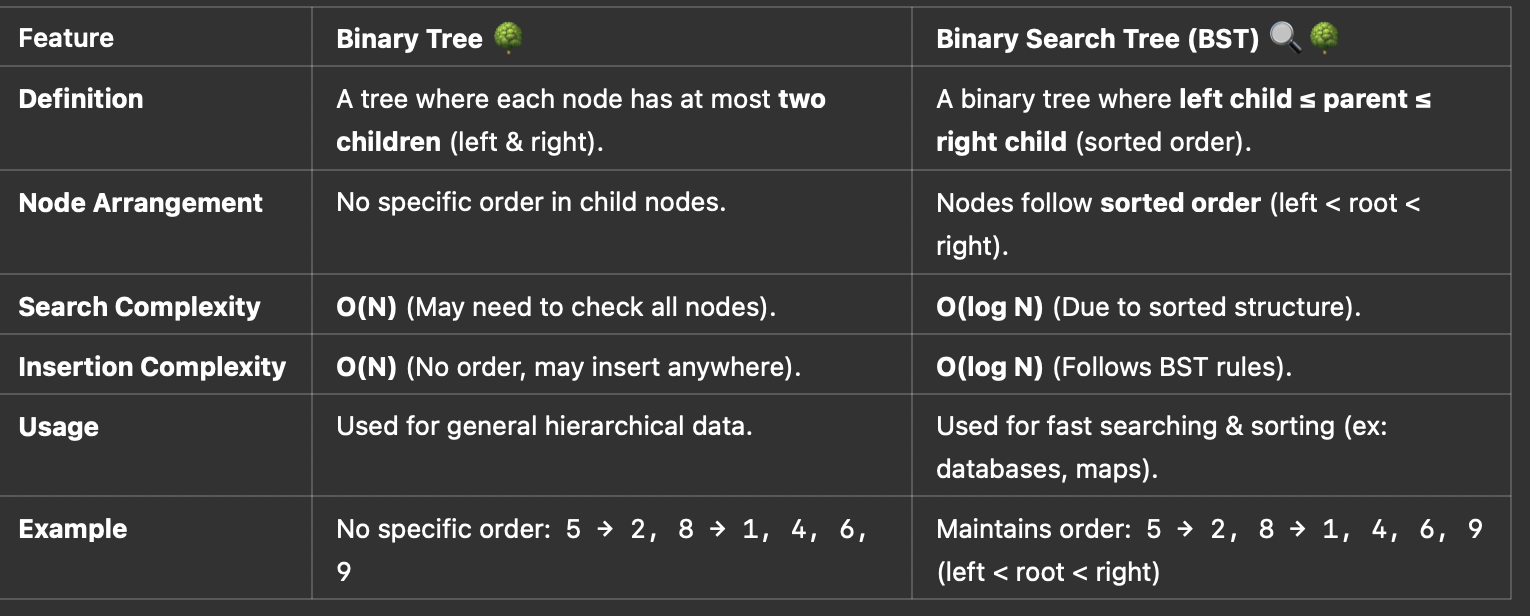

In [ ]:
class TreeNode:
    def __init__(self, val=0):
        self.val = val
        self.left = None
        self.right = None

class BST:
    def __init__(self):
        self.root = None

    def insert(self, root, val):
        """Inserts a node in the BST."""
        if not root:
            return TreeNode(val)
        if val < root.val:
            root.left = self.insert(root.left, val)
        else:
            root.right = self.insert(root.right, val)
        return root

# Example Usage
bst = BST()
root = None
values = [10, 5, 15, 2, 7, 12, 18, 1]  # Creating BST
for val in values:
    root = bst.insert(root, val)

print(root, root.left, root.right)
midpoint = bst.find_farthest_node(root)
print("Midpoint of Diameter Path:", midpoint.val)

In [ ]:
A Balanced Tree is a binary tree where the difference between the heights of the left and right subtrees of any node is at most 1.

|height_left - height_right| <= 1
    for all nodes and sub-nodes.

C- Balanced Tree, instead of 1, we use a constant.

def is_balanced(root):
    if root is None:
        return (True, 0)   # (is_balanced, height)
    is_left_balanced, left_height = is_balanced(root.left)
    is_right_balanced, right_height = is_balanced(root.right)
    return (abs(left_height - right_height) <= 1  and is_left_balanced and is_right_balanced, 1+ max(left_height, right_height))



In [ ]:
# Balance a binary tree, first store all the nodes to an array and then construct a tree.
def store_inorder(root, nodes):
    if not root:
        return
    store_inorder(root.left, nodes)
    nodes.append(root)
    store_inorder(root.right, nodes)

# Step 2: Construct a balanced tree from the sorted list
def build_balanced_tree(nodes, start, end):
    """It uses the middle element of the list as the root to ensure balance:
	1.	Pick the middle node as root.
	2.	Recursively build the left subtree from the left half of the list.
	3.	Recursively build the right subtree from the right half of the list.
    """
    if start > end:
        return None
    
    mid = (start + end) // 2
    root = nodes[mid]  # Pick middle element as root

    root.left = build_balanced_tree(nodes, start, mid - 1)
    root.right = build_balanced_tree(nodes, mid + 1, end)
    
    return root

# Step 3: Wrapper function to balance the binary tree
def balanceBST(root):
    nodes = []
    store_inorder(root, nodes)  # Get sorted nodes list
    return build_balanced_tree(nodes, 0, len(nodes) - 1) 

In [ ]:
def is_bst_valid(node, min_value, max_value):
    if node is None:
        return True

    if not (min_value < node.value < max_value):
        return false
        
    is_left_valid = is_bst_valid(node.left, min_value, node.value)
    is_right_valid = is_bst_valid(node.right, node.vale, max_value)

    return is_left_valid and is_right_valid and min_value < node.value < max_value


def largest_bst(node):

    def helper(node):
        if node is None:
            return (0, True, float('-inf'), float('inf'))  # size, is_bst_valid, left_max, right_min

        left_size, is_left_subtree_valid, left_min, left_max = helper(node.left)
        right_size, is_right_subtree_valid, right_min, right_max = helper(node.left)

        
            

In [ ]:
# Binary Search in an Array
1. Indexing, can get element in O(1)
2. Insertion and deletion in O(N)
3. Search in O(log N)

# Link list
1. Insertion, deletion, and search in O(N)

# Binary Search Tree Properties
1. In order travesal gives the sorted array.
2. But with one in-order traversed array, there can be multiple tree.
3. Searching an element in BST is O(height)
    - In worst case, it can be O(N), as if height = No. of nodes.
    - It can be O(log N), if tree is balanced.

Algorithms to check if a tree is a valid Binary Search Tree.
1. Do Inorder traversal and the ouput array should be sorted.
2. Using min and max values.


def is_valid_bst(root, min_val=float('-inf'), max_val=float('inf')):
    """Check if a binary tree is a valid BST.
    Top-down: Passing constraints (min_val, max_val) FROM parent → to children
            Information flow down the tree
    """
    if not root:
        return True  # Empty tree is a valid BST

    if not (min_val < root.val < max_val):
        return False  # Node violates BST property

    is_left_bst_valid = is_valid_bst(root.left, min_val, root.val)
    is_right_bst_valid = is_valid_bst(root.right, root.val, max_val)
    # Check left and right subtrees with updated constraints
    return (is_left_bst_valid and is_right_bst_valid)

def is_valid_bst(root, parent_left, parent_right):
    """Check if a binary tree is a valid BST."""
    if not root:
        return True  # Empty tree is a valid BST

    if (parent_left != None and root.value < parent_left.value)
        return False

    if (parent_right != None and root.value >= parent_right.value)
        return False
    
    is_left_bst_valid = is_valid_bst(root.left, parent_left, root)
    is_right_bst_valid = is_valid_bst(root.right, root, parent_right)
    # Check left and right subtrees with updated constraints
    return (is_left_bst_valid and is_right_bst_valid)


# Given a tree where root is not a valid BST, but a valid BST sub-tree exist. return a valid Binary Search sub-tree.
# Approach: Bottom-Up DFS. (Use Post-Order traversal)

def largest_bst_subtree(root):
        """
        Check BST Validity:
        	•	Left subtree’s max value < current node’s value.
        	•	Right subtree’s min value > current node’s value.
        """
    
    def dfs(node):
        if not node:
            return True, 0, float('inf'), float('-inf')
            # (is_bst, size, min, max)

        left_is_bst, left_size, left_min, left_max = dfs(node.left)
        right_is_bst, right_size, right_min, right_max = dfs(node.right)

        # Check BST condition
        if left_is_bst and right_is_bst and left_max < node.val < right_min:
            
            size = left_size + right_size + 1
            min_val = min(left_min, node.val)
            max_val = max(right_max, node.val)

            return True, size, min_val, max_val

        # Not a BST → return largest BST found so far
        return False, max(left_size, right_size), 0, 0

    return dfs(root)[1]



# Given a BST, return kth largest elment.
# Approach: For sorting related, only in-order will work.
# But In-order return, the ascending sorted array. To get the descending sorted array, user reverse In-order traversal.
Sol 1: Do a in-order traversal and return the n-k th element. But this requires an additional array.
Sol 2: Directly implement a reverse in-order traversal and return the first k-th element.
def kth_largest_element(root, k):
    """Finds the kth largest element in a BST using reverse inorder traversal."""
    count = 0
    result = None

    def reverse_inorder(node):
        nonlocal count, result
        if not node or result is not None:
            return
        
        # First, visit the right subtree
        reverse_inorder(node.right)
        
        # Process the current node
        count += 1
        if count == k:
            result = node.val
            return
        
        # Then, visit the left subtree
        reverse_inorder(node.left)

    reverse_inorder(root)
    return result

In [ ]:
# Approach: Tree Divide & Conquer + Recursion
# Question: Given a range 1 to N,  Generate all possible Unique Binary Search Trees.

Idea: Every number can be the ROOT

Apporach: Divide & Conquer + Recursion
    - If problem says, return  all unique structures
class TreeNode:
    def __init__(self, val):
        self.val = val
        self.left = None
        self.right = None


def generateTrees(n):
    if n == 0:
        return []

    def build(start, end):
        if start > end:
            return [None]   # Important base case,  it allows the nested loop below to still execute once and attach None as a leaf child.

        all_trees = []

        for root_val in range(start, end + 1):
            # Generate all left subtrees
            left_trees = build(start, root_val - 1)

            # Generate all right subtrees
            right_trees = build(root_val + 1, end)

            # Combine left and right
            for left in left_trees:
                for right in right_trees:
                    root = TreeNode(root_val)
                    root.left = left
                    root.right = right
                    all_trees.append(root)

        return all_trees

    return build(1, n)

# 5. Tree Path Problems

In [ ]:
Queries from root to a Node
Questions Type
Whenever you see:
	•	Path
	•	Sum
	•	Root to leaf
	•	Collect all paths
	•	Target node
	•	Backtracking

# Solution: Append → Check → Left → Right → Pop
Explore all root-to-leaf paths
    - Maintain state while going down
    - Undo state while coming back

When we should not use this pattern: 
    - You only need a VALUE, not the PATH

In [ ]:
###################### Tree - Path Problems ######################

# 1️⃣ Find Path from Root → Given Node
def find_path(root, target, path):
    """ Path Problem: Returns the path from root to target using a recursive DFS.  Traversal: Left -> Root -> Right"
    use Inorder traversal.
    1.	Traverse the left subtree.
    2.	Visit the current node (check if it’s the target).
    3.	Traverse the right subtree.
    4.	If the target is not found in either subtree, backtrack by removing the current node from the path.

    Idea: Push when going down
          Pop when coming up
    """
    if not root:
        return False

    # Add current node
    path.append(root.val)

    # If target found
    if root.val == target:
        return True

    # Search left or right
    left_found = find_path(root.left, target, path)
    right_found = find_path(root.right, target, path)

    if left_found or right_found: # If current element is part of the answer, then no need to remove it.
        return True

    # BACKTRACK — this node is not on the path
    path.pop()
    return False


# 3️⃣ Print All Root → Leaf Paths
 def all_root_to_leaf_paths(root, path, result):

    if not root:
        return

    path.append(root.val)

    # If leaf node
    if root.left is None and root.right is None:
        result.append(path.copy())

    all_root_to_leaf_paths(root.left, path, result)
    all_root_to_leaf_paths(root.right, path, result)

    # Backtrack
    path.pop()    


# 4️⃣ Check If Path With Given Sum Exists
def has_path_sum(root, target_sum, current_sum):

    if not root:
        return False

    current_sum += root.val

    # Problem-specific condition
    if root.left is None and root.right is None:
        return current_sum == target_sum

    left = has_path_sum(root.left, target_sum, current_sum)
    right = has_path_sum(root.right, target_sum, current_sum)

    return left or right


# 5️⃣ Return All Root → Leaf Paths With Given Sum
def path_sum_all(root, target_sum, path, result):

    if not root:
        return

    path.append(root.val)
    current_sum += node.val

    # Problem-specific condition
    if root.left is None and root.right is None and current_sum == target_sum:
        result.append(path.copy())

    path_sum_all(root.left, target_sum, path, result)
    path_sum_all(root.right, target_sum, path, result)

    path.pop()    

# 6. Sub-Tree Problems

In [ ]:
######################## Sub-Tree Problems ##########################

class TreeNode:
    def __init__(self, val):
        self.val = val
        self.left = None
        self.right = None

# Return Nodes of sub-tree having equal sum
def find_equal_subtrees(root):

    subtree_sum_map = {}   # sum -> first node with this sum
    result = []

    def dfs(node):
        if not node:
            return 0

        left_sum = dfs(node.left)
        right_sum = dfs(node.right)

        current_sum = node.val + left_sum + right_sum

        # If we already saw this sum before
        if current_sum in subtree_sum_map:
            result.append((subtree_sum_map[current_sum], node))
        else:
            subtree_sum_map[current_sum] = node

        return current_sum

    dfs(root)

    return result  # list of pairs of nodes

# 7. Comparing Trees

In [ ]:
######################### Comparing Trees #################
# Comparing Tree

1. If two trees are exactly same.
Check if Pre-order and In-order traversal are exactly same for both trees.

OR

def check_identical(root1, root2):
    if root1 == root2 == None:
       return True
    elif root1 == None or root2 == None
        return False

    is_left_equal = check_identical(root1.left, root2.left)
    is_right_equal = check_identical(root1.right, root2.right)
    return root1.Value == root2.Value and is_left_equal and is_right_equal



# IsoMorphic Trees
# Both trees have the same structure (even though left and right children are swapped).

def are_isomorphic(root1, root2):
    # Base Cases
    if not root1 and not root2:
        return True  # Both trees are empty
    if not root1 or not root2:
        return False  # One of the trees is empty
    if root1.val != root2.val:
        return False  # Root values are different

    # Check two cases:
    # 1. No swapping: Compare left-left and right-right
    # 2. Swapping: Compare left-right and right-left
    return (are_isomorphic(root1.left, root2.left) and are_isomorphic(root1.right, root2.right)) or \
           (are_isomorphic(root1.left, root2.right) and are_isomorphic(root1.right, root2.left))

# 8. Tree Views

In [1]:
#################### Tree Views ####################
        1
       / \
      2   3
     /     \
    4       5


def left_view_recursive(root):
    """Prints the left view of a binary tree using DFS."""
    result = []
    levels = {}

    def dfs(node, depth):
        if not node:
            return

        # If first time reaching this depth, store the node

        if depth == len(result):
            result.append(node.val) # 1 -> 2 -> 4

        dfs(node.left, depth + 1)
        dfs(node.right, depth + 1)

        # Uncomment, to print in reverse order via post-order traversal.
        if depth not in levels:
            levels[depth] = node.val # 4 -> 2 -> 1


    dfs(root, 0)
    print("Left View:", result)
    print("Left View in reverse order:", levels)



def right_view_recursive(root):
    """Prints the right view of a binary tree using DFS."""
    result = []

    def dfs(node, depth):
        if not node:
            return

        # If first time reaching this depth, store the node
        if depth == len(result):
            result.append(node.val)

        dfs(node.right, depth + 1)
        dfs(node.left, depth + 1)

    dfs(root, 0)
    print("Right View:", result)


# Level order traversal -----------------------------------------------------

def left_view(root):
    """Prints the left view of a binary tree using level-order traversal."""
    if not root:
        return
    
    queue = deque([root])
    leftmost_at_level = {}

    while queue:
        node, level = queue.popleft()

        # If level is seen for the first time, store it
        if level not in leftmost_at_level:
            leftmost_at_level[level] = node.val

        if node.left:
            queue.append((node.left, level + 1))
        if node.right:
            queue.append((node.right, level + 1))

    print("Left View:", list(leftmost_at_level.values()))


def right_view(root):
    """Prints the right view of a binary tree using level-order traversal."""
    if not root:
        return
    
    queue = deque([(root, 0)])
    rightmost_at_level = {}

    while queue:
        node, level = queue.popleft()

        # Store the last node encountered at each level
        rightmost_at_level[level] = node.val  

        if node.left:
            queue.append((node.left, level + 1))
        if node.right:
            queue.append((node.right, level + 1))

    print("Right View:", list(rightmost_at_level.values()))



def top_view(root):
    """
    Using the level order traversal, Consider vertical lines (line with root node has zero value and if we go left we do -1 and on right. +1
    ie. hd
    """
    if not root:
        return []

    top_view_map = {}  # Stores {HD: Node Value}
    queue = deque([(root, 0)])  # (Node, Horizontal Distance)

    while queue:
        node, hd = queue.popleft()

        # Store only the first node seen at each HD
        if hd not in top_view_map:                    # For bottom view, we will just remove this if conditon, so it will overrite values.
            top_view_map[hd] = node.val

        # Traverse left (HD - 1)
        if node.left:
            queue.append((node.left, hd - 1))
        
        # Traverse right (HD + 1)
        if node.right:
            queue.append((node.right, hd + 1))

    # Print top view in order of sorted HDs
    print("Top View:", [top_view_map[hd] for hd in sorted(top_view_map.keys())])

In [ ]:
# Tree Bounday Traversal

def boundary_traversal(root):
    """1. Add root node.
       2. Traverse left branch of main tree, Add left node if exist else add right node. Do Not add leaf nodes.
       3. Run on root node, and add all leaf nodes.
       4. Traverse right branch of main tree, Add left node if exist else add right node. Do Not add leaf nodes. (Add in reverse order)
    """
    if not root:
        return []

    result = []
    if root:
        result.append(root.val)

    def left_boundary(node):
        """Collects the left boundary excluding leaf nodes."""
        while node:
            if node.left or node.right:
                result.append(node.val)
            node = node.left if node.left else node.right

    def right_boundary(node):
        """Collects the right boundary excluding leaf nodes (stores in reverse)."""
        temp = []
        while node:
            if node.left or node.right:
                temp.append(node.val)
            node = node.right if node.right else node.left
        result.extend(reversed(temp))

    def add_leaves(node):
        """Adds all leaf nodes using DFS."""
        if not node:
            return
        if not node.left and not node.right:
            result.append(node.val)
        add_leaves(node.left)
        add_leaves(node.right)

    left_boundary(root.left)
    add_leaves(root)
    right_boundary(root.right)

    print("Boundary Traversal:", result)

        1
       / \
      2   3
     / \   \
    4   5   6
       / \
      7   8

Left View      : 1   2   4   7
Right View     : 1   3   6   8
Bottom View    : 4   2   7   8   6
Boundary View  : 1   2   4   7   8   6   3

In [ ]:
class TreeNode:
    def __init__(self, val):
        self.val = val
        self.left = None
        self.right = None

# Sample Tree
root = TreeNode(1)
root.left = TreeNode(2)
root.right = TreeNode(3)
root.left.left = TreeNode(4)
root.left.right = TreeNode(5)
root.right.right = TreeNode(6)
root.right.right.left = TreeNode(7)

"""
                1
            2     3
           4 5     6 
                  7
"""


left_view_recursive(root)


# 9. Tree Data Agumentation

In [ ]:
# Data Agumentation

Given a BST and Q number of queries to the K th largest element.
- To optimize such problems, we first add some data to each nodes and then process queries. o(N) for pre-prossing and o(height) for each query.

def update_size(root):
    """ Bottom-Up apporach (ie. post order traversal) Updates the size of each node in the BST. """
    if not root:
        return 0  # Null node contributes 0 to size

    left_size = update_size(root.left)   # Size of left subtree
    right_size = update_size(root.right) # Size of right subtree

    root.size = left_size + right_size + 1  # Total size including self
    return root.size

def kth_smallest(root, k):
    """Find the k-th smallest element using subtree sizes (O(logN) time).
       We already populated the sizes, Now the tree will act as a BST.
       Idea:
           This is a BST, so solution will be like a Binary Search.
           left_size = number of nodes in left subtree
           The root is the (left_size + 1) th smallest element
    """
    while root:
        left_size = root.left.size if root.left else 0

        if left_size + 1 == k:  # Found k-th smallest
            return root.val
        elif left_size + 1 > k:  # Move left
            root = root.left
        else:  # Move right
            k -= (left_size + 1)  # This means we skip, left subtree + root and trying to find node in the right side.
            root = root.right
    return None 

# 10. LCA

In [ ]:
# LCA

def find_LCA_BST(root, p, q):
    """ BST is like a sorted array.
    
    If both p and q are smaller → go LEFT
    If both p and q are larger  → go RIGHT
    Else → THIS node is LCA
    """
    if not root:
        return None

    if root.val > p.val and root.val > q.val:
        return find_LCA_BST(root.left, p, q)

    if root.val < p.val and root.val < q.val:
        return find_LCA_BST(root.right, p, q)

    return root  # LCA found


def find_LCA(root, p, q):
    """Non-BST Tree. Finds the Lowest Common Ancestor of nodes p and q in a Binary Tree.
    Steps:
    	1.	Base Case: If the root is None, return None.
    	2.	If root is either p or q, return root (an ancestor itself).
    	3.	Recursively search for p and q in the left and right subtrees.
    	4.	Case Handling:
        	•	If both p and q are found in different subtrees → root is LCA.
        	•	If both are in the same subtree → return the non-null result.

        1
         \
          2
          - For node 1 and 2, LCA can be 1


         -Find LCA of 4 and 7, ie. 2
            2
          4   5
             1 7
            - When at 4, it return itself, ie. 4 to parent 2
            - When at 7, it return itself, ie. 7 to parent 5
            - 1 returns None to parent
            - 5 return 7
            - When root is 2, in that case, both left and right are not null, so it returns 2 as LCA
               
    """
    if not root or root == p or root == q:
        return root  # Base case: Found p or q, or reached end of tree

    left_lca = find_LCA(root.left, p, q)   # Search in left subtree
    right_lca = find_LCA(root.right, p, q) # Search in right subtree

    if left_lca and right_lca:
        return root  # If both sides return non-null, root is LCA
    
    return left_lca if left_lca else right_lca  

# 11. Euler Tour

In [ ]:
# Euler Tour
- It is primarily used for pre-computation, to process multiple N queries.
Euler Tour is a traversal technique that allows us to process a tree using a single traversal while storing entry, exit, and intermediate information of each node.

Euler Tour of a tree is a DFS-based traversal where we visit each node three times:
	1.	First Entry (Preorder visit)
	2.	Middle Visit (Inorder if applicable)
	3.	Final Exit (Postorder visit)

        1
       / \
      2   3
     / \   \
    4   5   6

1 → 2 → 4 → 4 → 2 → 5 → 5 → 2 → 1 → 3 → 3 → 6 → 6 → 3 → 1

def euler_tour(root, tour):
    """Performs an Euler Tour and records visits."""
    if not root:
        return

    # First visit (Preorder)
    tour.append(root.val)

    # Left subtree
    euler_tour(root.left, tour)

    # Second visit (Inorder, optional)
    tour.append(root.val)

    # Right subtree
    euler_tour(root.right, tour)

    # Third visit (Postorder)
    tour.append(root.val)


# Questions of Eular
- Subtree
    - Sum of subtree of node u
    - Max in subtree of node u
    - Count nodes in subtree
- Multiple queries
- Offline queries
- Fast repeated queries
- Path queries
    - Find sum from root to node u
- Ancestor check


# Approach
Step 1 → Build tree (adjacency list)
Step 2 → Perform Euler Tour (DFS)
Step 3 → Flatten tree
Step 4 → Support multiple fast queries

# 12. Tree Generic Problems

In [ ]:
################## Tree Generic Problems ##################

# 2️⃣ Flatten Binary Tree to Linked List (Preorder)
def flatten(root):

    def dfs(node):
        if not node:
            return None

        left_tail = dfs(node.left)
        right_tail = dfs(node.right)

        if left_tail:
            left_tail.right = node.right
            node.right = node.left
            node.left = None

        return right_tail or left_tail or node

    dfs(root)

# 9️⃣ Convert BST to Doubly Linked List

def bst_to_dll(root):

    head = prev = None

    def inorder(node):
        nonlocal head, prev

        if not node:
            return

        inorder(node.left)

        if not head:
            head = node
        else:
            prev.right = node
            node.left = prev

        prev = node

        inorder(node.right)

    inorder(root)
    return head
# 4️⃣ Recover Swapped BST
def recover_bst(root):

    first = second = prev = None

    def inorder(node):
        nonlocal first, second, prev

        if not node:
            return

        inorder(node.left)

        if prev and node.val < prev.val:
            if not first:
                first = prev
            second = node

        prev = node

        inorder(node.right)

    inorder(root)

    first.val, second.val = second.val, first.val    


# 5️⃣ Binary Tree Cameras
def min_camera_cover(root):

    cameras = 0

    def dfs(node):
        nonlocal cameras

        if not node:
            return 2  # Covered

        left = dfs(node.left)
        right = dfs(node.right)

        if left == 0 or right == 0:
            cameras += 1
            return 1  # Has camera

        if left == 1 or right == 1:
            return 2  # Covered

        return 0  # Not covered

    if dfs(root) == 0:
        cameras += 1

    return cameras


# 7️⃣ Nodes at Distance K from Target

def distance_k(root, target, k):

    parent = {}

    def map_parent(node, par):
        if not node:
            return
        parent[node] = par
        map_parent(node.left, node)
        map_parent(node.right, node)

    map_parent(root, None)

    visited = set()
    result = []

    def dfs(node, distance):
        if not node or node in visited:
            return

        visited.add(node)

        if distance == k:
            result.append(node.val)
            return

        dfs(node.left, distance + 1)
        dfs(node.right, distance + 1)
        dfs(parent[node], distance + 1)

    dfs(target, 0)
    return result    

# 13. Serialize and Deserialize

In [41]:

class serialize_deserialize:
    def serialize(self, root):
        """Encodes a tree to a single string."""
        def dfs(node):
            if not node:
                result.append("None")  # Store null nodes
                return
            result.append(str(node.val))
            dfs(node.left)
            dfs(node.right)

        result = []
        dfs(root)
        return ",".join(result)  # Convert list to string

    def deserialize(self, data):
        """Decodes the encoded data to tree."""
        def dfs():
            val = nodes.popleft()
            if val == "None":
                return None
            node = TreeNode(int(val))
            node.left = dfs()
            node.right = dfs()
            return node

        nodes = collections.deque(data.split(","))  # Convert string to queue
        return dfs()

    def serialize(self, root):
        """Encodes a tree to a single string using BFS."""
        if not root:
            return "None"
        
        result = []
        queue = deque([root])

        while queue:
            node = queue.popleft()
            if node:
                result.append(str(node.val))
                queue.append(node.left)
                queue.append(node.right)
            else:
                result.append("None")
        
        return ",".join(result)

    def deserialize(self, data):
        """Decodes a serialized tree using iterative BFS."""
        if data == "None":
            return None

        values = data.split(",")
        root = TreeNode(int(values[0]))
        queue = deque([root])
        index = 1

        while queue:
            node = queue.popleft()

            # Process left child
            if values[index] != "None":
                node.left = TreeNode(int(values[index]))
                queue.append(node.left)
            index += 1

            # Process right child
            if values[index] != "None":
                node.right = TreeNode(int(values[index]))
                queue.append(node.right)
            index += 1

        return root
serialize_deserialize().serialize(root)

'1,2,4,None,None,5,None,None,3,None,6,7,None,None,None'

# 14. Morris Traversal (Complex)

# Morris Traversal
Time Complexity: O(N)
Space Complexity: O(1)


It uses the concept of treaded Binary Tree.
Output same as Inorder traversal: 4 2 5 6 1 3
Steps: 
1. If left is null, then print root and move to right
2. If left is not null, then before moving to left
   - Connect last node (or right most node) of left sub-tree to the root. (Ex: create yellow threads) and move to left.
3. If thread is already created, then remove the thread and move to right.

Example execution of following:
1. Currently at 1: Create a thread from last node of left tree to current node. (ie. from 6 to 1) and then move to left (i.e 2)
2. Currently at 2: Create a thread (ie from 4 to 2) and move to 4.
3. Currently at 4: Use the newly link to move to next node (ie 2).
4. Currently at 2: See if there is a link that points to 2, if yes cutt-off that link and move to right.


Questions:
- All questions where Tree Traversal (In-order & Pre-order) without recursion or extra memory.
- Kth smallest element, just use in-order traversal and keep a counter that increments on each element visited., check and break loop when kth element is found.
- Convert to single or doubly link list

Approach: Instead of printing elements, we do the required operation.

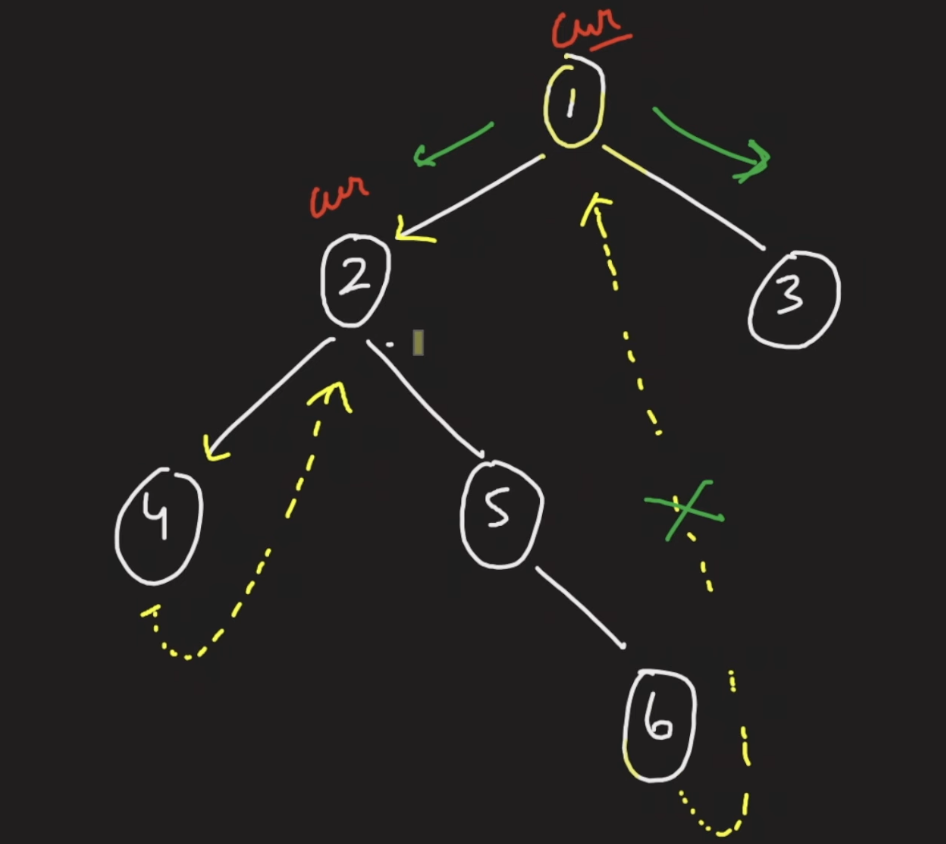

In [ ]:

def morris_inorder(root):
    """ Morris Traversal for in-order traversal with O(1) space. """
    current = root
    while current:
        if current.left is None:
            print(current.val, end=" ")  # Process node
            current = current.right
        else:
            # Find predecessor (rightmost node in left subtree)
            predecessor = current.left
            while predecessor.right and predecessor.right != current:
                predecessor = predecessor.right

            if predecessor.right is None:
                predecessor.right = current  # Create a thread
                current = current.left
            else:
                predecessor.right = None  # Remove thread
                print(current.val, end=" ")  # Process node
                current = current.right

